In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive(1).zip to archive(1).zip


In [ ]:
import os
os.listdir('/content')

['.config', 'archive(1).zip', 'sample_data']

In [ ]:
import zipfile

zip_path = "/content/archive(1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os
os.listdir("/content/dataset")

['ALL']

In [ ]:
os.listdir("/content/dataset/ALL")[:10]

['JK_a14.wav',
 'DC_n13.wav',
 'KL_f14.wav',
 'DC_sa14.wav',
 'KL_sa06.wav',
 'DC_h07.wav',
 'KL_f13.wav',
 'JK_d02.wav',
 'KL_f08.wav',
 'JK_a09.wav']

In [ ]:
dataset_path = "/content/dataset/ALL"

In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/ALL


In [ ]:
!pip install librosa soundfile scikit-learn

In [ ]:
import librosa
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

In [ ]:
emotion_map = {
    "a":"angry",
    "d":"disgust",
    "f":"fear",
    "h":"happy",
    "n":"neutral",
    "sa":"sad",
    "su":"surprise"
}

In [ ]:
def extract_features(file_path):

    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')

    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)

    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)

    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)

    return np.hstack((mfcc, chroma, mel))

In [ ]:
data = []
labels = []

dataset_path = "/content/dataset/ALL"

for file in os.listdir(dataset_path):

    if file.endswith(".wav"):

        file_path = os.path.join(dataset_path, file)

        emotion_code = file.split("_")[1]

        emotion_code = ''.join([i for i in emotion_code if not i.isdigit()])

        label = emotion_map.get(emotion_code)

        if label is not None:
            features = extract_features(file_path)

            data.append(features)
            labels.append(label)

print("Total samples:", len(data))

Total samples: 0


In [ ]:
X = np.array(data)
y = np.array(labels)

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/ALL


In [ ]:
import os

files = os.listdir("/content/dataset/ALL")
print("Total files:", len(files))
print(files[:10])

Total files: 480
['JK_a14.wav', 'DC_n13.wav', 'KL_f14.wav', 'DC_sa14.wav', 'KL_sa06.wav', 'DC_h07.wav', 'KL_f13.wav', 'JK_d02.wav', 'KL_f08.wav', 'JK_a09.wav']


In [ ]:
data = []
labels = []

dataset_path = "/content/dataset/ALL"

for file in os.listdir(dataset_path):

    if file.endswith(".wav"):

        file_path = os.path.join(dataset_path, file)

        try:
            # Extract features
            features = extract_features(file_path)

            # Extract emotion from filename
            parts = file.split("_")

            if len(parts) > 1:
                emotion_code = parts[1]

                emotion_code = ''.join([c for c in emotion_code if not c.isdigit()])

                if emotion_code in emotion_map:
                    label = emotion_map[emotion_code]

                    data.append(features)
                    labels.append(label)

        except:
            pass

print("Total samples:", len(data))

Total samples: 0


In [ ]:
import os

files = os.listdir("/content/dataset/ALL")

print("Total files:", len(files))
print(files[:20])

Total files: 480
['JK_a14.wav', 'DC_n13.wav', 'KL_f14.wav', 'DC_sa14.wav', 'KL_sa06.wav', 'DC_h07.wav', 'KL_f13.wav', 'JK_d02.wav', 'KL_f08.wav', 'JK_a09.wav', 'JE_n04.wav', 'DC_f10.wav', 'KL_n03.wav', 'DC_n03.wav', 'JK_f01.wav', 'KL_n07.wav', 'JK_h01.wav', 'JK_n02.wav', 'JE_n22.wav', 'JK_sa08.wav']


In [ ]:
emotion_map = {
    "a": "angry",
    "d": "disgust",
    "f": "fear",
    "h": "happy",
    "n": "neutral",
    "sa": "sad"
}

In [ ]:
import librosa
import numpy as np

def extract_features(file_path):

    audio, sample_rate = librosa.load(file_path)

    mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)
    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)
    mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)

    return np.hstack((mfcc, chroma, mel))

In [ ]:
import os

data = []
labels = []

dataset_path = "/content/dataset/ALL"

for file in os.listdir(dataset_path):

    if file.endswith(".wav"):

        file_path = os.path.join(dataset_path, file)

        parts = file.split("_")

        emotion_part = parts[1]   # example a14.wav

        # remove numbers and .wav
        emotion_code = ''.join([i for i in emotion_part if i.isalpha()])

        if emotion_code in emotion_map:

            label = emotion_map[emotion_code]

            features = extract_features(file_path)

            data.append(features)
            labels.append(label)

print("Total samples:", len(data))

Total samples: 0


In [ ]:
import re

for file in os.listdir("/content/dataset/ALL")[:10]:
    emotion = re.search(r'_([a-z]+)', file).group(1)
    print(file, " -> ", emotion)

JK_a14.wav  ->  a
DC_n13.wav  ->  n
KL_f14.wav  ->  f
DC_sa14.wav  ->  sa
KL_sa06.wav  ->  sa
DC_h07.wav  ->  h
KL_f13.wav  ->  f
JK_d02.wav  ->  d
KL_f08.wav  ->  f
JK_a09.wav  ->  a


In [ ]:
import os
import re

data = []
labels = []

dataset_path = "/content/dataset/ALL"

for file in os.listdir(dataset_path):

    if file.endswith(".wav"):

        file_path = os.path.join(dataset_path, file)

        try:
            # Extract emotion
            emotion_code = re.search(r'_([a-z]+)', file).group(1)

            # Extract audio features
            features = extract_features(file_path)

            data.append(features)
            labels.append(emotion_code)

        except:
            pass

print("Total samples:", len(data))

Total samples: 480


In [ ]:
import numpy as np

X = np.array(data)
y = np.array(labels)

print(X.shape)
print(len(y))

(480, 180)
480


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
import numpy as np

X = np.array(data)
y = np.array(labels)

print("Feature shape:", X.shape)
print("Labels:", len(y))

Feature shape: (480, 180)
Labels: 480


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Encoded labels:", y[:10])

Encoded labels: [0 4 2 5 5 3 2 1 2 0]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (384, 180)
Testing samples: (96, 180)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")

Accuracy: 76.04166666666666 %


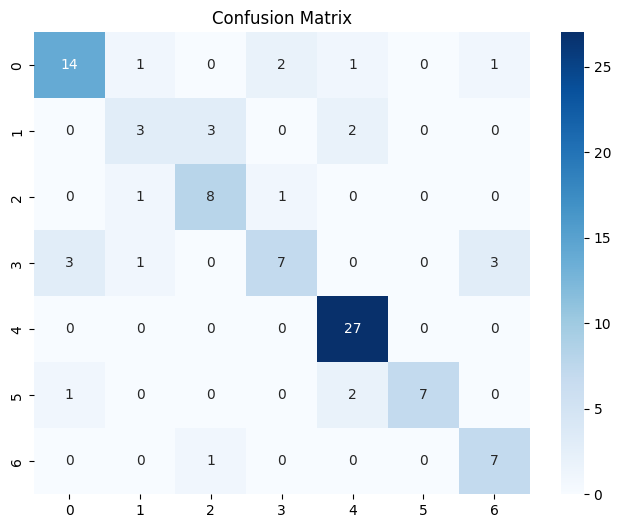

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()